In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, norm
from IPython.display import display

In [5]:
carpeta = r"C:\Users\DELL\Desktop\Aspectos de auditoría\Automatización FORTAMUN"
archivos = glob.glob(os.path.join(carpeta, "*.xlsx"))
dataframes = {}
for archivo in archivos:
  nombre_base = os.path.basename(archivo)
  dataframes[nombre_base] = pd.read_excel(archivo)
for nombre, df in dataframes.items():
  if len(df) > 50:
    print(f"Procesando el archivo: {nombre}")
    print(f"Tiene {len(df)} filas.")

Procesando el archivo: Anexo 9.3 GD (gastos diversos sin contrato) VS1.xlsx
Tiene 623 filas.
Procesando el archivo: Anexo 9.3 GD PART OCT DIC.xlsx
Tiene 355 filas.
Procesando el archivo: Anexo 9.3 GD TONILA ENESEP.xlsx
Tiene 698 filas.
Procesando el archivo: Anexo 9.3 Jilotan FAIS.xlsx
Tiene 742 filas.
Procesando el archivo: Anexo 9.3 Jilotan FORTA.xlsx
Tiene 742 filas.
Procesando el archivo: Anexo 9.3 Jilotan PAR.xlsx
Tiene 743 filas.
Procesando el archivo: Anexo 9.3.xlsx
Tiene 235 filas.
Procesando el archivo: Anexo 9.4 TONILA ENESEP.xlsx
Tiene 169 filas.
Procesando el archivo: Anexo_9.3_GDLUNA.xlsx
Tiene 96 filas.


In [8]:
archivos_filtrados = {}
for nombre, df in dataframes.items():
    df_limpio = df.copy()
    df_limpio.columns = df_limpio.columns.str.replace('\n', ' ').str.strip()
    archivos_filtrados[nombre] = df_limpio

for nombre, df in dataframes.items():
  if len(df) > 50:
    fila_titulos_idx = 14  # Valor por defecto si no encuentra nada
    for i in range(min(20, len(df))):
      
      texto_fila = df.iloc[i].fillna("").astype(str).str.upper().values

      if any(
          "NOMBRE" in str(celda)
          or "DESCRIPCIÓN" in str(celda)
          or "MONTO" in str(celda)
          for celda in texto_fila
      ):
        fila_titulos_idx = i
        break

    df_recortado = df.iloc[fila_titulos_idx:].copy()
    df_recortado.columns = df_recortado.iloc[0]
    df_recortado = df_recortado[1:]
    df_recortado.columns = (
        df_recortado.columns.astype(str).str.replace("\n", " ").str.strip()
    )
    archivos_filtrados[nombre] = df_recortado

In [13]:
for nombre, df in archivos_filtrados.items():
  if "MONTO PAGADO CON FORTAMUN" in df.columns:
    df.rename(
        columns={"MONTO PAGADO CON FORTAMUN": "MONTO_FINAL"}, inplace=True
    )
  elif "MONTO PAGADO CON PARTICIPACIONES A MUN" in df.columns:
    df.rename(
        columns={"MONTO PAGADO CON PARTICIPACIONES A MUN": "MONTO_FINAL"},
        inplace=True,
    )
  elif "MONTO PAGADO CON PARTICIPACIONES A ENTIDADES" in df.columns:
      df.rename(
        columns={"MONTO PAGADO CON PARTICIPACIONES A ENTIDADES": "MONTO_FINAL"},
        inplace=True,
    )

  if "MONTO_FINAL" in df.columns:
    df["MONTO_FINAL"] = (
        df["MONTO_FINAL"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df["MONTO_FINAL"] = pd.to_numeric(df["MONTO_FINAL"], errors="coerce")

  
  columna_fecha = "FECHA DE ADQUISICIÓN (dd/mm/yyyy)"
  if columna_fecha in df.columns:
    df[columna_fecha] = pd.to_datetime(
        df[columna_fecha], format="%d/%m/%Y", errors="coerce"
    )

  columnas_a_validar = [
      col for col in ["RFC", "MONTO_FINAL"] if col in df.columns
  ]
  if columnas_a_validar:
    df.dropna(subset=columnas_a_validar, inplace=True)

  archivos_filtrados[nombre] = df

In [16]:
for nombre, df in archivos_filtrados.items():
  if "MONTO_FINAL" in df.columns:
    print(f"--- Estadísticas de: {nombre} ---")
    print(df["MONTO_FINAL"].describe())
    print("\n")

--- Estadísticas de: Anexo 9.3 GD (gastos diversos sin contrato) VS1.xlsx ---
count      605.000000
mean      6585.597405
std       8474.357332
min         65.000000
25%       1871.190000
50%       3662.410000
75%       7437.000000
max      79969.270000
Name: MONTO_FINAL, dtype: float64


--- Estadísticas de: Anexo 9.3 GD PART OCT DIC.xlsx ---
count      339.000000
mean      3078.440708
std       5695.177076
min         11.000000
25%        581.400000
50%       1693.600000
75%       2806.555000
max      50000.000000
Name: MONTO_FINAL, dtype: float64


--- Estadísticas de: Anexo 9.3 GD TONILA ENESEP.xlsx ---
count      682.000000
mean      1822.335748
std       3370.587071
min         16.700000
25%        469.000000
50%       1083.840000
75%       1815.010000
max      37694.010000
Name: MONTO_FINAL, dtype: float64


--- Estadísticas de: Anexo 9.3 Jilotan FAIS.xlsx ---
count     2.000000
mean     59.160000
std      27.888291
min      39.440000
25%      49.300000
50%      59.160000
75%   

In [18]:
print("\n--- TOP 5 PROVEEDORES CON MAYOR MONTO TOTAL ACUMULADO ---")

for nombre, df in archivos_filtrados.items():
  df_temp = df.copy()

  columnas_proveedor_posibles = [
      "NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL",
      "NOMBRE, DENOMINACION Y/O RAZON SOCIAL",  
      "NOMBRE, DENOMINACIÓN Y/O RAZÓN SOCIAL",  
      "PROVEEDOR O CONTRATISTA",
      "PROVEEDOR",
  ]

  for col_posible in columnas_proveedor_posibles:
    if col_posible in df_temp.columns:
      df_temp.rename(columns={col_posible: "PROVEEDOR"}, inplace=True)
      break

  if "PROVEEDOR" in df_temp.columns and "MONTO_FINAL" in df_temp.columns:
    print(f"\nReporte de: {nombre}")

    top_proveedores = (
        df_temp.groupby("PROVEEDOR")["MONTO_FINAL"].sum().round(2)
    )
    print(top_proveedores.sort_values(ascending=False).head(5))


--- TOP 5 PROVEEDORES CON MAYOR MONTO TOTAL ACUMULADO ---

Reporte de: Anexo 9.3 GD (gastos diversos sin contrato) VS1.xlsx
PROVEEDOR
MUNICIPIO DE SAN JUAN DE LOS LAGOS JALISCO    1504338.93
QUALITAS COMPAÑIA DE SEGUROS, S.A. DE C.V.     372959.80
QUALITAS COMPAÑIA DE SEGUROS SA. DE C.V.       105006.25
JOSE DE JESUS MARTIN FLORES                     90102.00
AUTOMOVILES CGE DE ZACATECAS SA DE CV           86077.03
Name: MONTO_FINAL, dtype: float64

Reporte de: Anexo 9.3 GD PART OCT DIC.xlsx
PROVEEDOR
MUNICIPIO DE TONILA JALISCO        223740.00
OSBALDO HEREDIA MAGAÑA              46214.66
MAREL TERMAL                        42195.06
SUSANA SANCHEZ BONOS                35106.20
CONSTRUCCIONES R. RUIZ SA DE CV     33282.00
Name: MONTO_FINAL, dtype: float64

Reporte de: Anexo 9.3 GD TONILA ENESEP.xlsx
PROVEEDOR
SUSANA SANCHEZ BONOS             51625.76
LUIS FERNANDO OCHOA GUTIERREZ    51368.15
JOEL LORENZANA VALLE             46616.96
JOSE GUADALUPE PONCE DIAZ        46589.01
MIGUEL ANG

In [19]:
print("\n--- GASTO TOTAL Y CONTRATOS POR CLASIFICADOR (2000, 3000) ---")

for nombre, df in archivos_filtrados.items():
  df_temp = df.copy()

  columnas_clasificador_posibles = [
      "PARTIDA ESPECÍFICA DEL CLASIFICADOR POR OBJETO DEL GASTO",
      "PARTIDA ESPECIFICA DEL CLASIFICADOR POR OBJETO DEL GASTO",  
      "PARTIDA ESPECÍFICA DEL CLASIFICADOR",
      "PARTIDA",
  ]

  for col_posible in columnas_clasificador_posibles:
    if col_posible in df_temp.columns:
      df_temp.rename(columns={col_posible: "CLASIFICADOR"}, inplace=True)
      break

  if "CLASIFICADOR" in df_temp.columns and "MONTO_FINAL" in df_temp.columns:
    print(f"\nReporte de: {nombre}")

    partida_gasto = (
        df_temp.groupby("CLASIFICADOR")
        .agg(
            Total_Gastado=("MONTO_FINAL", "sum"),
            Numero_Transacciones=("MONTO_FINAL", "count"),
        )
        .round(2)
    )

    print(partida_gasto)


--- GASTO TOTAL Y CONTRATOS POR CLASIFICADOR (2000, 3000) ---

Reporte de: Anexo 9.3 GD (gastos diversos sin contrato) VS1.xlsx
              Total_Gastado  Numero_Transacciones
CLASIFICADOR                                     
2000             2453976.56                   413
3000             1495309.86                   191
5000               35000.01                     1

Reporte de: Anexo 9.3 GD PART OCT DIC.xlsx
              Total_Gastado  Numero_Transacciones
CLASIFICADOR                                     
2000              453546.92                   191
3000              590044.48                   148

Reporte de: Anexo 9.3 GD TONILA ENESEP.xlsx
              Total_Gastado  Numero_Transacciones
CLASIFICADOR                                     
211                44132.86                    28
212                 2158.32                     6
214                21043.08                     4
215                10638.64                     4
216                56599.90     

In [27]:
print("\n--- TRANSCACIÓN MÁS ALTA REGISTRADA POR MUNICIPIO ---")

for nombre, df in archivos_filtrados.items():
  df_temp = df.copy()

  columnas_proveedor_posibles = [
      "NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL",
      "NOMBRE, DENOMINACION Y/O RAZON SOCIAL",
      "NOMBRE, DENOMINACIÓN Y/O RAZÓN SOCIAL",
      "PROVEEDOR O CONTRATISTA",
      "PROVEEDOR",
  ]

  for col_posible in columnas_proveedor_posibles:
    if col_posible in df_temp.columns:
      df_temp.rename(columns={col_posible: "PROVEEDOR"}, inplace=True)
      break

  if "PROVEEDOR" in df_temp.columns and "MONTO_FINAL" in df_temp.columns:
        transaccion_max = df_temp.loc[df_temp["MONTO_FINAL"].idxmax()]
        
        # Corrección de sangría (alineados perfectamente con transaccion_max)
        print(f"\nArchivo: {nombre}")
        print(f" Proveedor: {transaccion_max['PROVEEDOR']}")
        print(f" Monto: ${transaccion_max['MONTO_FINAL']:.2f}") # Formato corregido dentro de {}

        if "DESCRIPCIÓN" in df_temp.columns:
            print(f" Descripción: {transaccion_max['DESCRIPCIÓN']}")
        elif "DESCRIPCION" in df_temp.columns:
            print(f" Descripción: {transaccion_max['DESCRIPCION']}")


--- TRANSCACIÓN MÁS ALTA REGISTRADA POR MUNICIPIO ---

Archivo: Anexo 9.3 GD (gastos diversos sin contrato) VS1.xlsx
 Proveedor: NAYELI SOTO CHAVEZ
 Monto: $79969.27
 Descripción: PAGO DE TONER PARA SISTEMAS

Archivo: Anexo 9.3 GD PART OCT DIC.xlsx
 Proveedor: MUNICIPIO DE TONILA JALISCO
 Monto: $50000.00
 Descripción:  PAGO DE NOMINA POR TRABAJOS DE MANTENIMIENTO EN EL MUNICIPIO

Archivo: Anexo 9.3 GD TONILA ENESEP.xlsx
 Proveedor: JOSE GUADALUPE PONCE DIAZ
 Monto: $37694.01
 Descripción: COMPRA DE NEUMATICOS Y DEMAS REFACCIONES UTILIZADOS EN REPARACION DE VEHICULOS OFICIALES.

Archivo: Anexo 9.3 Jilotan FAIS.xlsx
 Proveedor: BBVA MEXICO SA 
 Monto: $78.88
 Descripción: Servicios financieros y bancarios

Archivo: Anexo 9.3 Jilotan FORTA.xlsx
 Proveedor: COMPU EXPRESS SOFTWARE Y MANTENIMIENTO 
 Monto: $32625.00
 Descripción: Mantenimiento de impresoras

Archivo: Anexo 9.3 Jilotan PAR.xlsx
 Proveedor: CONSTRUCCIONES DAVARO
 Monto: $38240.00
 Descripción:  Pago por traslado de motonivel

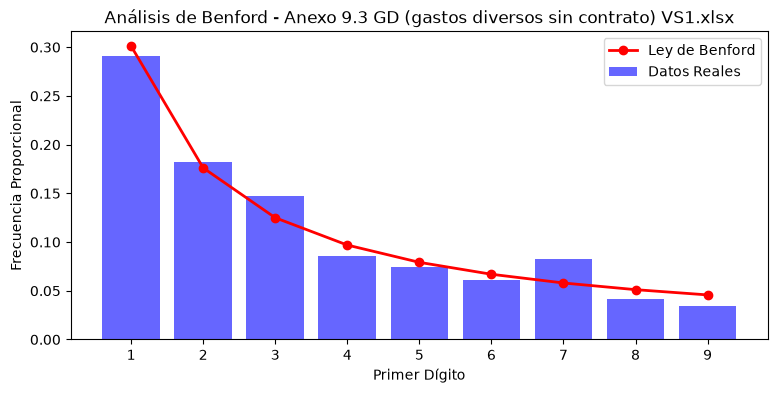

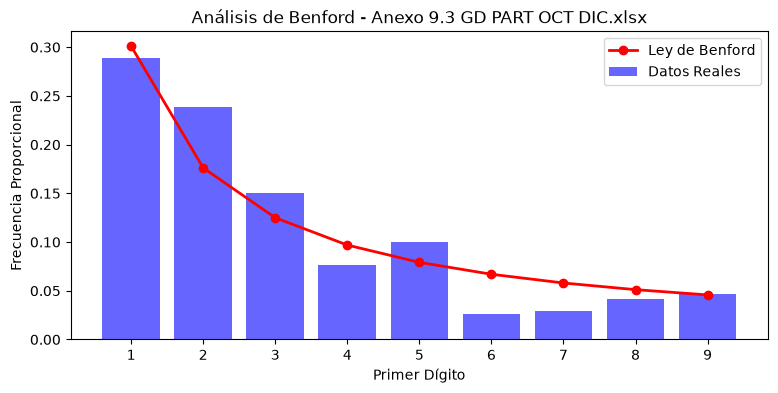

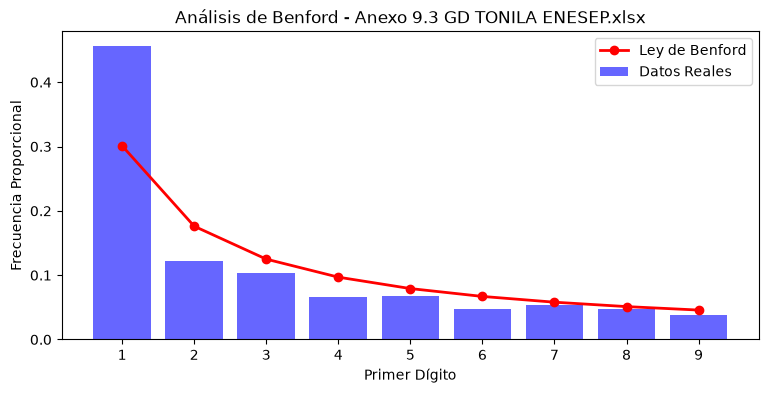



El archivo 'Anexo 9.3 Jilotan FAIS.xlsx' tiene muy pocos datos válidos para el análisis de Benford.
El archivo 'Anexo 9.3 Jilotan FORTA.xlsx' tiene muy pocos datos válidos para el análisis de Benford.


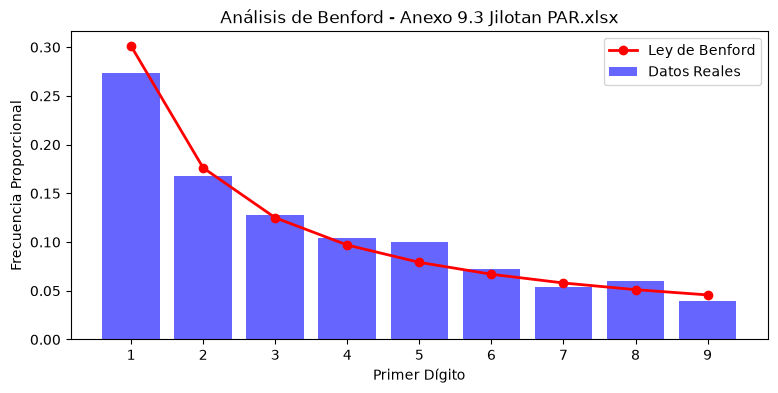

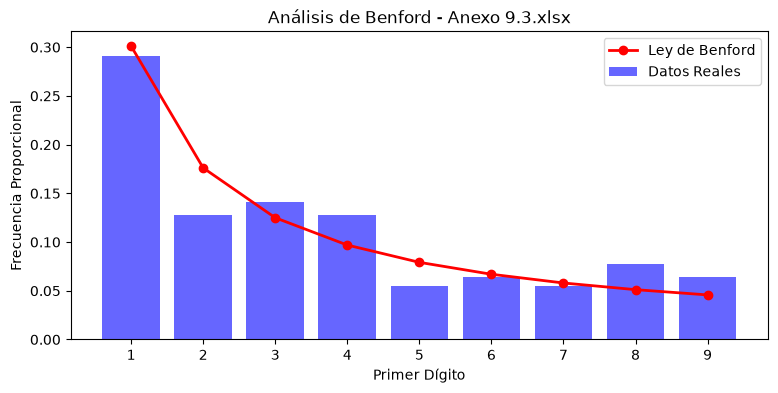

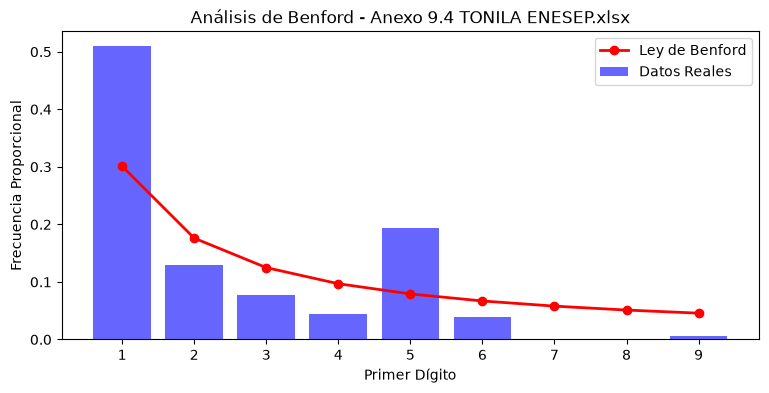

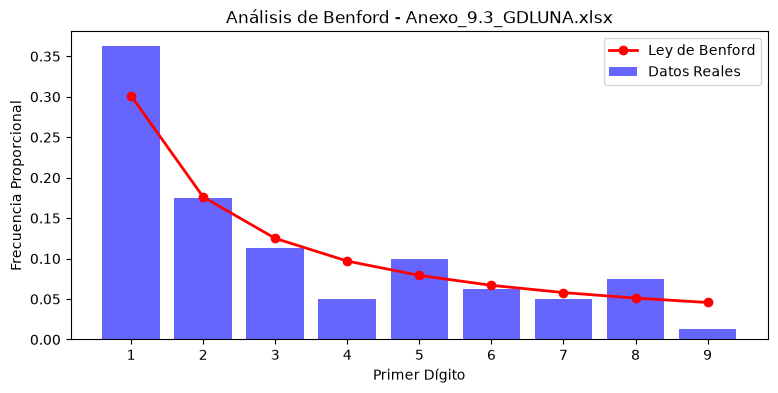

In [29]:
for nombre, df in archivos_filtrados.items():
  if "MONTO_FINAL" in df.columns:

    df_benford = df[df["MONTO_FINAL"] > 0].dropna(subset=["MONTO_FINAL"]).copy()

    if df_benford.empty:
      continue

    df_benford["PRIMER_DIGITO"] = (
        df_benford["MONTO_FINAL"].astype(str).str.lstrip("0. $-,").str[0]
    )

    df_benford = df_benford[
        df_benford["PRIMER_DIGITO"].isin([str(x) for x in range(1, 10)])
    ]
    df_benford["PRIMER_DIGITO"] = df_benford["PRIMER_DIGITO"].astype(int)

    if len(df_benford) < 10:
      print(
          f"El archivo '{nombre}' tiene muy pocos datos válidos para el análisis de Benford."
      )
      continue

    conteos = (
        df_benford["PRIMER_DIGITO"].value_counts(normalize=True).sort_index()
    )

    conteos = conteos.reindex(range(1, 10), fill_value=0)

    digitos = np.arange(1, 10)
    frecuencias_benford = np.log10(1 + 1 / digitos)

    plt.figure(figsize=(9, 4))
    plt.bar(
        conteos.index,
        conteos.values,
        alpha=0.6,
        color="blue",
        label="Datos Reales",
    )
    plt.plot(
        digitos,
        frecuencias_benford,
        color="red",
        marker="o",
        linewidth=2,
        label="Ley de Benford",
    )

    plt.xlabel("Primer Dígito")
    plt.ylabel("Frecuencia Proporcional")
    plt.title(f"Análisis de Benford - {nombre}")
    plt.xticks(digitos)
    plt.legend()
    plt.show()
    print("\n" + "=" * 50 + "\n")

In [33]:
print("--- ANÁLISIS ESTADÍSTICO (CHI-CUADRADA Y PRUEBA Z) ---")
digitos = np.arange(1, 10)
frecuencias_benford = np.log10(1 + 1 / digitos)

for nombre, df in archivos_filtrados.items():
  if "MONTO_FINAL" in df.columns:

    df_benford = df[df["MONTO_FINAL"] > 0].dropna(subset=["MONTO_FINAL"]).copy()
    df_benford["PRIMER_DIGITO"] = (
        df_benford["MONTO_FINAL"].astype(str).str.lstrip("0. $-,").str[:1]
    )
    df_benford = df_benford[
        df_benford["PRIMER_DIGITO"].isin([str(x) for x in range(1, 10)])
    ]
    df_benford["PRIMER_DIGITO"] = df_benford["PRIMER_DIGITO"].astype(int)

    N = len(df_benford)
    if N < 30:
      print(
          f"\n '{nombre}' saltado: Solo tiene {N} registros válidos (se requieren mínimo 30)."
      )
      continue

    conteos_observados = (
        df_benford["PRIMER_DIGITO"].value_counts().reindex(digitos, fill_value=0)
    )
    frecuencias_observadas = conteos_observados.values

    # Frecuencias esperadas absolutas
    frecuencias_esperadas = frecuencias_benford * N

# ====================================
# PRUEBA CHI-CUADRADA (Prueba Global)
# ====================================      
    frec_esp_ajustada = frecuencias_esperadas * (
        frecuencias_observadas.sum() / frecuencias_esperadas.sum()
    )
    chi2_stat, p_val_chi2 = chisquare(frecuencias_observadas, frec_esp_ajustada)

    print(f"\n=========================================")
    print(f"ARCHIVO: {nombre}")
    print(f"Total de registros analizados (N): {N}")
    print(f"-----------------------------------------")
    print(f"Prueba Chi-Cuadrada Global:")
    print(f"  Estadístico Chi2: {chi2_stat:.4f}")
    print(f"  P-Valor: {p_val_chi2:.6f}")

    if p_val_chi2 < 0.05:
      print(
          "CONCLUSIÓN GLOBAL: LOS GASTOS NO SIGUEN LA LEY DE BENFORD (Anomalía detectada)"
      )
    else:
      print(
          "CONCLUSIÓN GLOBAL: Los gastos se comportan con normalidad según la Ley de Benford."
      )

    print(f"\nPrueba Z Individual por Dígito:")
    print(f"  Dígito | Obs %  | Benford % | Z-Score | Estado")

# =====================================================================      
# PRUEBA Z INDIVIDUAL (Para encontrar anomalías específicas por dígito)
# =====================================================================      
    for d, obs, esp_prop in zip(
        digitos, frecuencias_observadas, frecuencias_benford
    ):
      p_obs = obs / N
      p_esp = esp_prop

      # Error estándar de la proporción
      se = np.sqrt((p_esp * (1 - p_esp)) / N)

      # Z-score con corrección de continuidad de Benford
      z_score = (abs(p_obs - p_esp) - (1 / (2 * N))) / se if se > 0 else 0
      if (abs(p_obs - p_esp) - (1 / (2 * N))) < 0:
        z_score = 0  # Ajuste si la diferencia es menor que la corrección

      # Umbral crítico de Z = 1.96 para un 95% de confianza
      estado = "Desviación" if z_score > 1.96 else "Normal"

      print(
          f"     {d}   | {p_obs*100:5.1f}% | {p_esp*100:8.1f}% | {z_score:7.2f} | {estado}"
      )

--- ANÁLISIS ESTADÍSTICO (CHI-CUADRADA Y PRUEBA Z) ---

ARCHIVO: Anexo 9.3 GD (gastos diversos sin contrato) VS1.xlsx
Total de registros analizados (N): 605
-----------------------------------------
Prueba Chi-Cuadrada Global:
  Estadístico Chi2: 13.0240
  P-Valor: 0.111026
CONCLUSIÓN GLOBAL: Los gastos se comportan con normalidad según la Ley de Benford.

Prueba Z Individual por Dígito:
  Dígito | Obs %  | Benford % | Z-Score | Estado
     1   |  29.1% |     30.1% |    0.50 | Normal
     2   |  18.2% |     17.6% |    0.32 | Normal
     3   |  14.7% |     12.5% |    1.59 | Normal
     4   |   8.6% |      9.7% |    0.84 | Normal
     5   |   7.4% |      7.9% |    0.36 | Normal
     6   |   6.1% |      6.7% |    0.49 | Normal
     7   |   8.3% |      5.8% |    2.51 | Desviación
     8   |   4.1% |      5.1% |    1.01 | Normal
     9   |   3.5% |      4.6% |    1.20 | Normal

ARCHIVO: Anexo 9.3 GD PART OCT DIC.xlsx
Total de registros analizados (N): 339
-----------------------------------

In [36]:
print("--- EXTRACCIÓN FORENSE DE REGISTROS ANÓMALOS ---")
archivos_con_alerta = {
    "Anexo 9.4 TONILA ENESEP.xlsx": 5,
    "Anexo 9.3 GD TONILA ENESEP.xlsx": 1,
    "Anexo_9.3_GDLUNA.xlsx": 5, 
}

for nombre_archivo, digito_sospechoso in archivos_con_alerta.items():
  if nombre_archivo in archivos_filtrados:
    df_temp = archivos_filtrados[nombre_archivo].copy()

    for col in [
        "NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL",
        "PROVEEDOR O CONTRATISTA",
        "PROVEEDOR",
    ]:
      if col in df_temp.columns:
        df_temp.rename(columns={col: "PROVEEDOR"}, inplace=False)
        break

    df_temp["PRIMER_DIGITO"] = (
        df_temp["MONTO_FINAL"].astype(str).str.lstrip("0. $-,").str[:1]
    )

    df_anomalo = df_temp[df_temp["PRIMER_DIGITO"] == str(digito_sospechoso)]

    print(f"\n==================================================")
    print(
        f"ANÁLISIS DE RIESGO: {nombre_archivo} (Dígito a inspeccionar: {digito_sospechoso})"
    )
    print(f"Total de facturas bajo sospecha: {len(df_anomalo)}")
    print(f"--------------------------------------------------")

    if "PROVEEDOR" in df_anomalo.columns:
      top_sospechosos = (
          df_anomalo.groupby("PROVEEDOR")["MONTO_FINAL"]
          .agg(Total_Acumulado="sum", Facturas_Emitidas="count")
          .sort_values(by="Total_Acumulado", ascending=False)
          .head(5)
      )
      print(top_sospechosos)
    else:
      print(df_anomalo[["MONTO_FINAL"]].head(5))


--- EXTRACCIÓN FORENSE DE REGISTROS ANÓMALOS ---

ANÁLISIS DE RIESGO: Anexo 9.4 TONILA ENESEP.xlsx (Dígito a inspeccionar: 5)
Total de facturas bajo sospecha: 30
--------------------------------------------------
13  MONTO_FINAL
15       5680.0
20       5680.0
25       5680.0
30       5680.0
34       5680.0

ANÁLISIS DE RIESGO: Anexo 9.3 GD TONILA ENESEP.xlsx (Dígito a inspeccionar: 1)
Total de facturas bajo sospecha: 311
--------------------------------------------------
13  MONTO_FINAL
17      1182.83
19      1249.26
22     10047.70
24      1828.00
25      1956.00

ANÁLISIS DE RIESGO: Anexo_9.3_GDLUNA.xlsx (Dígito a inspeccionar: 5)
Total de facturas bajo sospecha: 8
--------------------------------------------------
13  MONTO_FINAL
27      5916.00
29      5964.72
47       545.20
48      5757.08
74      5302.36


In [58]:
archivo_sospechoso = "Anexo 9.3 GD TONILA ENESEP.xlsx"

if archivo_sospechoso in archivos_filtrados:
    df_tonila = archivos_filtrados[archivo_sospechoso].copy()

    for col in [
        "NOMBRE, DENOMINACIÓN Y/O RAZON SOCIAL",
        "NOMBRE, DENOMINACION Y/O RAZON SOCIAL",
        "PROVEEDOR O CONTRATISTA",
        "PROVEEDOR",
    ]:
        if col in df_tonila.columns:
            df_tonila.rename(columns={col: "PROVEEDOR"}, inplace=True)
            break

    for col in ["DESCRIPCIÓN", "DESCRIPCION", "CONCEPTO"]:
        if col in df_tonila.columns:
            df_tonila.rename(columns={col: "DESCRIPCIÓN"}, inplace=True)
            break

    df_tonila["PRIMER_DIGITO"] = (
        df_tonila["MONTO_FINAL"].astype(str).str.lstrip("0. $-,").str[:1]
    )

    df_anomalo = df_tonila[df_tonila["PRIMER_DIGITO"] == "1"].copy()

    print(f"=== REPORTE DE EXTRACCIÓN FORENSE: {archivo_sospechoso} ===")
    print(f"Total de registros con Dígito 1: {len(df_anomalo)} de {len(df_tonila)}")
    print(
        f"Monto total acumulado en este dígito: ${df_anomalo['MONTO_FINAL'].sum():,.2f}\n"
    )

    print(" TOP 5 PROVEEDORES QUE ACAPARAN EL DÍGITO 1:")
    top_prov = (
        df_anomalo.groupby("PROVEEDOR")["MONTO_FINAL"]
        .agg(Total_Dinero="sum", Cantidad_Facturas="count")
        .sort_values(by="Total_Dinero", ascending=False)
        .head(5)
    )
    print(top_prov)
    print("-" * 60)

    print(" MONTOS EXACTOS MÁS REPETIDOS EN EL DÍGITO 1:")
    montos_repetidos = (
        df_anomalo["MONTO_FINAL"]
        .value_counts()
        .head(5)
        .reset_index(name="Veces_Repetido")
    )
    print(montos_repetidos)
    print("-" * 60)

    print(" MUESTRA DE REGISTROS MÁS ALTOS CON DÍGITO 1 (Para revisión física):")
    columnas_ver = [
        col
        for col in ["PROVEEDOR", "MONTO_FINAL", "DESCRIPCIÓN", "FECHA_LUM"]
        if col in df_anomalo.columns or col in ["PROVEEDOR", "MONTO_FINAL"]
    ]
    
    columnas_finales = ["PROVEEDOR", "MONTO_FINAL"]
    if "DESCRIPCIÓN" in df_anomalo.columns:
        columnas_finales.append("DESCRIPCIÓN")

    print(
        df_anomalo.sort_values(by="MONTO_FINAL", ascending=False)[
            columnas_finales
        ].head(5)
    )

=== REPORTE DE EXTRACCIÓN FORENSE: Anexo 9.3 GD TONILA ENESEP.xlsx ===
Total de registros con Dígito 1: 311 de 682
Monto total acumulado en este dígito: $541,477.01

 TOP 5 PROVEEDORES QUE ACAPARAN EL DÍGITO 1:
                                         Total_Dinero  Cantidad_Facturas
PROVEEDOR                                                               
LUIS FERNANDO OCHOA GUTIERREZ                44576.99                 21
MIGUEL ANGEL SANCHEZ MORALES                 36929.90                 23
JOEL LORENZANA VALLE                         28910.84                 10
TUBERIAS Y SANITARIOS VENEGAS EN COLIMA      27223.38                 15
SUSANA SANCHEZ BONOS                         23966.40                  2
------------------------------------------------------------
 MONTOS EXACTOS MÁS REPETIDOS EN EL DÍGITO 1:
   MONTO_FINAL  Veces_Repetido
0      1276.00              10
1      1604.18               7
2      1720.00               7
3      1800.00               6
4      1392.00  

In [56]:
monto_sospechoso = 1276.00
df_misterio = df_anomalo[df_anomalo["MONTO_FINAL"] == monto_sospechoso]

print(f"=== DETALLE DE INVESTIGACIÓN: MONTO ${monto_sospechoso:,.2f} ===")
print(f"Registros encontrados: {len(df_misterio)}\n")

columnas_reporte = ["PROVEEDOR"]
if "DESCRIPCIÓN" in df_misterio.columns:
    columnas_reporte.append("DESCRIPCIÓN")

if "FECHA DE ADQUISICIÓN (dd/mm/yyyy)" in df_misterio.columns:
    columnas_reporte.append("FECHA DE ADQUISICIÓN (dd/mm/yyyy)")

df_misterio = df_misterio.rename(columns={"FECHA DE ADQUISICIÓN (dd/mm/yyyy)": "FECHA DE ADQUISICIÓN"})

if "FECHA DE ADQUISICIÓN (dd/mm/yyyy)" in columnas_reporte:
    columnas_reporte[columnas_reporte.index("FECHA DE ADQUISICIÓN (dd/mm/yyyy)")] = "FECHA DE ADQUISICIÓN"

print(df_misterio[columnas_reporte].to_string())

=== DETALLE DE INVESTIGACIÓN: MONTO $1,276.00 ===
Registros encontrados: 10

13               PROVEEDOR                                                               DESCRIPCIÓN FECHA DE ADQUISICIÓN
231  AURORA GARCIA VAZQUEZ  POLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO           2024-04-30
232  AURORA GARCIA VAZQUEZ  POLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO           2024-04-30
234  AURORA GARCIA VAZQUEZ  POLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO           2024-04-30
235  AURORA GARCIA VAZQUEZ  POLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO           2024-04-30
236  AURORA GARCIA VAZQUEZ  POLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO           2024-04-30
237  AURORA GARCIA VAZQUEZ  POLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO           2024-04-30
520                CONMETA  POLIZA POR CONCEPTO GASTOS VARIOS AL SERV

## Conclusión del Detalle de Investigación
A partir del desglose de los 10 registros identificados bajo el monto de **$1,276.00**, se observa una **alta ambigüedad en el campo `DESCRIPCIÓN`**. La etiqueta *"PÓLIZA POR CONCEPTO GASTOS VARIOS AL SERVICIO DEL MPIO DE TONILA JALISCO"* se repite de manera idéntica para múltiples transacciones en fechas distintas (abril y enero de 2024), y para proveedores diferentes (*AURORA GARCÍA VÁZQUEZ* y *CONMETA*). 

**Impacto:** El uso generalizado de descripciones genéricas como "gastos varios" limita la trazabilidad del gasto público, dificulta la conciliación automatizada e impide validar la naturaleza real de la erogación, lo que representa una **anomalía operativa o red flag** en términos de control interno y auditoría de desempeño.
